# <center style = 'color : white'> Wine Quality </center>

# <center>**Data preprocessing**</center>

# 1. Data Loading and Initial Inspection

In this section we:
- Import the main libraries
- Load the `wine.csv` dataset
- Get a first overview of the data structure



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1.1 Load the dataset
db = pd.read_csv("wine.csv")

In [ ]:
# 1.2 Basic preview
print("Shape of dataset:", db.shape)
display(db.head())      # first rows
display(db.tail())      # last rows

Shape of dataset: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [ ]:
# 1.3 Data types and non-null counts
print("db.info()")
db.info()

db.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
# 1.4 Basic statistics (numeric columns)
print("db.describe()")
display(db.describe().T)

db.describe()


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [ ]:
# 1.5 Check for missing values
print("Missing values per colum")
display(db.isnull().sum())

Missing values per colum


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


# 2. Basic Data Quality Checks

In this section we:
- Verify whether there are duplicated rows in the dataset and remove them if needed.
- Explicitly define the **target variable** (`quality`) and the **feature variables** (all other columns).
- Confirm that all features are numeric and ready for further analysis.

In [ ]:
# 2.1 Check for duplicated rows
num_duplicates = db.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 240


In [ ]:
if num_duplicates > 0:
    db = db.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", db.shape)

Duplicates removed. New shape: (1359, 12)


In [ ]:
num_duplicates = db.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 0


In [ ]:
# 2.2 Identify target and feature columns
target_col = "quality"   # this is our output variable
feature_cols = [col for col in db.columns if col != target_col]

print("\nTarget column:", target_col)
print("Feature columns:", feature_cols)


Target column: quality
Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


# 3. Visualization – Target Variable (Wine Quality)

In this section we:
- Analyze the distribution of the target variable `quality`, which represents the wine's quality score (from 3 to 8).
- Display the number of samples for each quality level using `value_counts()` to understand class frequencies.
- Create a bar chart to visualize class balance.
- Identify whether the dataset is balanced or imbalanced, which is important for selecting appropriate evaluation metrics in modeling.


## 3.1 Target Variable (Wine Quality)


Value counts for wine quality (sorted):
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


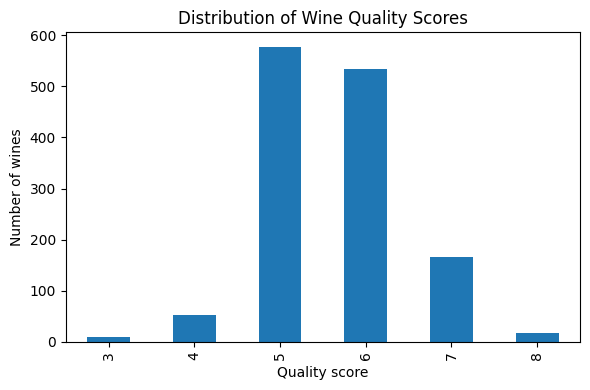

In [ ]:
print("Value counts for wine quality (sorted):")
print(db["quality"].value_counts().sort_index())

plt.figure(figsize=(6, 4))
db["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality score")
plt.ylabel("Number of wines")
plt.tight_layout()
plt.show()

## 3.2 Visualization – Distributions of Physicochemical Features

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


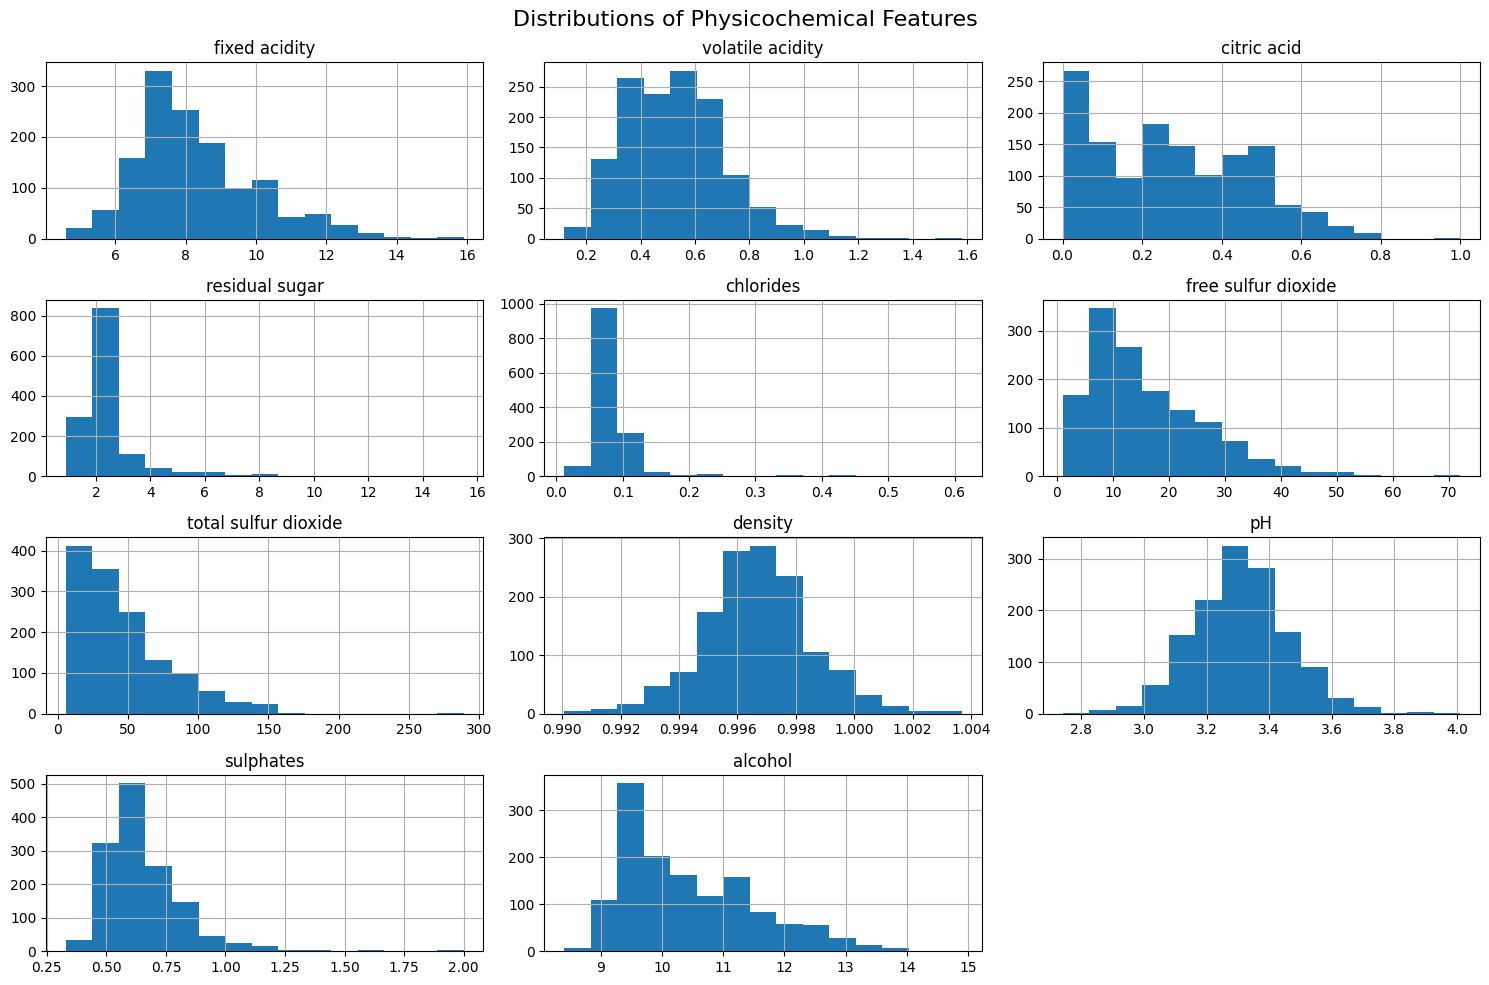

In [ ]:
display(db[feature_cols].describe().T)  # table, not a plot but useful

db[feature_cols].hist(bins=15, figsize=(15, 10))
plt.suptitle("Distributions of Physicochemical Features", fontsize=16)
plt.tight_layout()
plt.show()

**Imane: I added this for discussion (just a suggestion)**
Now, we'll interpret the histograms:



## 3.3 Visualization – Relationship Between Features and Quality (Boxplots)

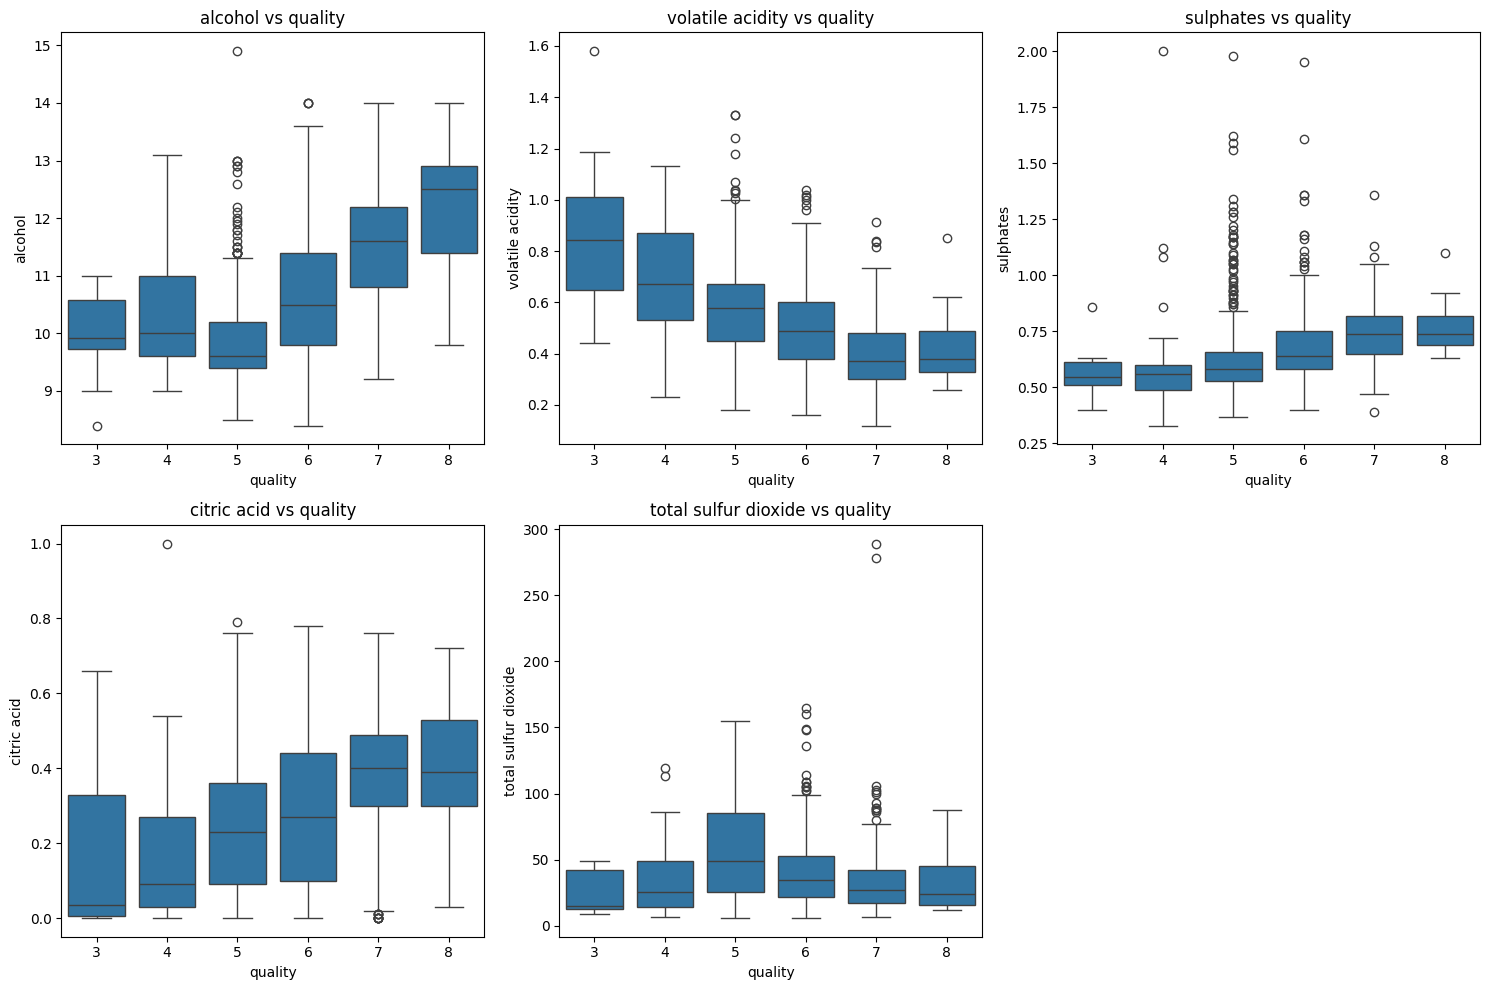

In [ ]:
selected_features = [
    "alcohol",
    "volatile acidity",
    "sulphates",
    "citric acid",
    "total sulfur dioxide"
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=db, x="quality", y=col)
    plt.title(f"{col} vs quality")
    plt.xlabel("quality")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Analysis – Class Balance of Wine Quality

The dataset contains wines with quality scores ranging from **3 to 8**.
Total absence of 0 and 10. => We might explain this by people avoiding the extreme scores during evaluation.

From the bar plot and value counts, we observe:

- Quality **5**: 577 samples  
- Quality **6**: 535 samples  
- Quality **7**: 167 samples  
- Quality **4**: 53 samples  
- Quality **8**: 17 samples  
- Quality **3**: 10 samples

This indicates a **moderate class imbalance**:

- The majority of samples fall into **quality 5 and 6**
- Very **few samples** exist for qualities **3, 4, and 8**

This gonna make our models predict "quality=6 or 5" for everything (We're exagerating).
We will address this imbalance using resampling techniques (SMOTE) and class weighting AFTER feature engineering and train/test split. This order prevents data leakage and ensures proper model evaluation.

## 4. Feature Encoding

In this dataset, all variables (input features and the target `quality`) are
numeric. There are no categorical/string features that require encoding
(one-hot or label encoding). Therefore, no encoding step is needed.


In [ ]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 127.5 KB


# 5. Correlation Analysis – Correlation Matrix and Heatmap

In this section we:
- Compute the correlation matrix between all numerical variables in the dataset.
- Identify how strongly each physicochemical feature is related to the target variable `quality`.
- Visualize the correlations using a heatmap to quickly spot positive and negative relationships.
- Detect highly correlated pairs of input features (multicollinearity), which may affect model performance.
- Interpret which variables show the strongest influence on wine quality (e.g., alcohol, volatile acidity, sulphates).


=== Correlation Matrix ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


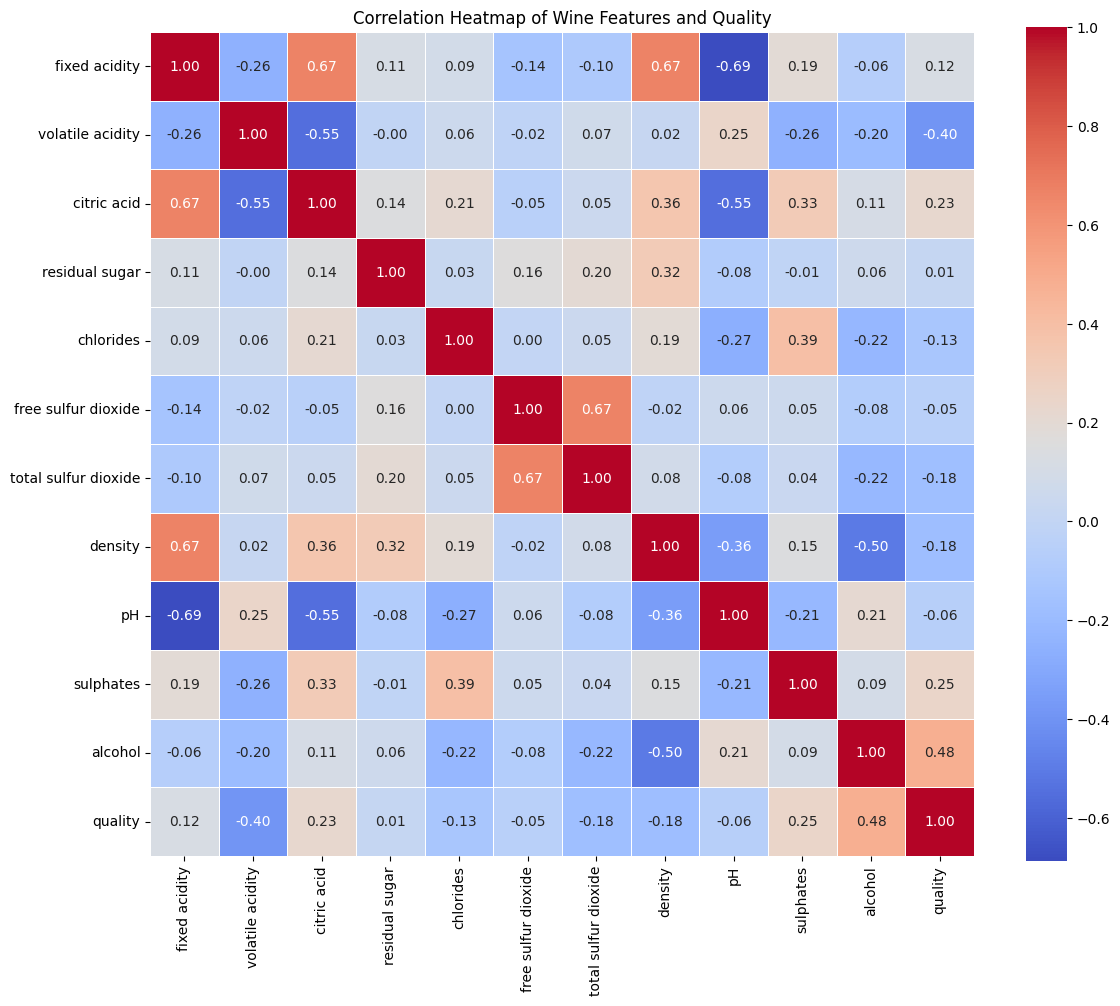


Correlation of each feature with quality:
quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


In [ ]:
# 6. Visualization – Correlation Matrix and Heatmap

corr_matrix = db.corr(numeric_only=True)

print("=== Correlation Matrix ===")
display(corr_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Wine Features and Quality")
plt.tight_layout()
plt.show()

print("\nCorrelation of each feature with quality:")
corr_with_quality = corr_matrix["quality"].sort_values(ascending=False)
print(corr_with_quality)

## 4. Feature Engeneering:
Wine quality depends on chemical balance and interactions, not just individual
measurements (Waterhouse et al., 2016; Ribéreau-Gayon et al., 2006). We'll
create features that capture:
- Acidity balance
- Preservation effectiveness  
- Flavor interactions
- Non-linear relationships

These features incorporate wine chemistry knowledge to help our model identify
what makes wines "good."

In [ ]:

# 1. Acidity Ratio: Good acids vs spoilage
db['acidity_ratio'] = db['fixed acidity'] / db['volatile acidity']

# 2. Free Sulfur Ratio: Preservation effectiveness
db['free_sulfur_ratio'] = db['free sulfur dioxide'] / db['total sulfur dioxide']

# 3. Alcohol-Sugar Balance: Dry vs sweet style
db['alcohol_sugar_balance'] = db['alcohol'] / (db['residual sugar'] + 1)

# 4. Total Acidity: Overall tartness
db['total_acidity'] = db['fixed acidity'] + db['volatile acidity'] + db['citric acid']

# 5. Alcohol × pH: Taste structure
db['alcohol_pH_interaction'] = db['alcohol'] * db['pH']

# 6. Alcohol Squared: Non-linear relationship
db['alcohol_squared'] = db['alcohol'] ** 2

print("✓ Created 6 engineered features")

✓ Created 6 engineered features


In [ ]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fixed acidity           1359 non-null   float64
 1   volatile acidity        1359 non-null   float64
 2   citric acid             1359 non-null   float64
 3   residual sugar          1359 non-null   float64
 4   chlorides               1359 non-null   float64
 5   free sulfur dioxide     1359 non-null   float64
 6   total sulfur dioxide    1359 non-null   float64
 7   density                 1359 non-null   float64
 8   pH                      1359 non-null   float64
 9   sulphates               1359 non-null   float64
 10  alcohol                 1359 non-null   float64
 11  quality                 1359 non-null   int64  
 12  acidity_ratio           1359 non-null   float64
 13  free_sulfur_ratio       1359 non-null   float64
 14  alcohol_sugar_balance   1359 non-null   

=== Correlation Matrix ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,acidity_ratio,free_sulfur_ratio,alcohol_sugar_balance,total_acidity,alcohol_pH_interaction,alcohol_squared
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024,0.631773,-0.117083,-0.225275,0.996213,-0.322344,-0.065645
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214,-0.794045,-0.084893,-0.110703,-0.201292,-0.067632,-0.197690
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057,0.687972,-0.162084,-0.132632,0.686084,-0.126808,0.105382
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640,0.027614,-0.086658,-0.773992,0.120663,0.017389,0.065926
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988,-0.027112,-0.107385,-0.130093,0.109633,-0.285888,-0.218675
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463,-0.066726,0.316253,-0.128203,-0.140834,-0.043386,-0.077756
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855,-0.139251,-0.381915,-0.258727,-0.086378,-0.208940,-0.207491
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252,0.231593,-0.261455,-0.617082,0.677618,-0.568611,-0.508711
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245,-0.436622,0.183392,0.200096,-0.686724,0.566580,0.212396
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835,0.264766,-0.003313,0.039465,0.189976,-0.000314,0.092180


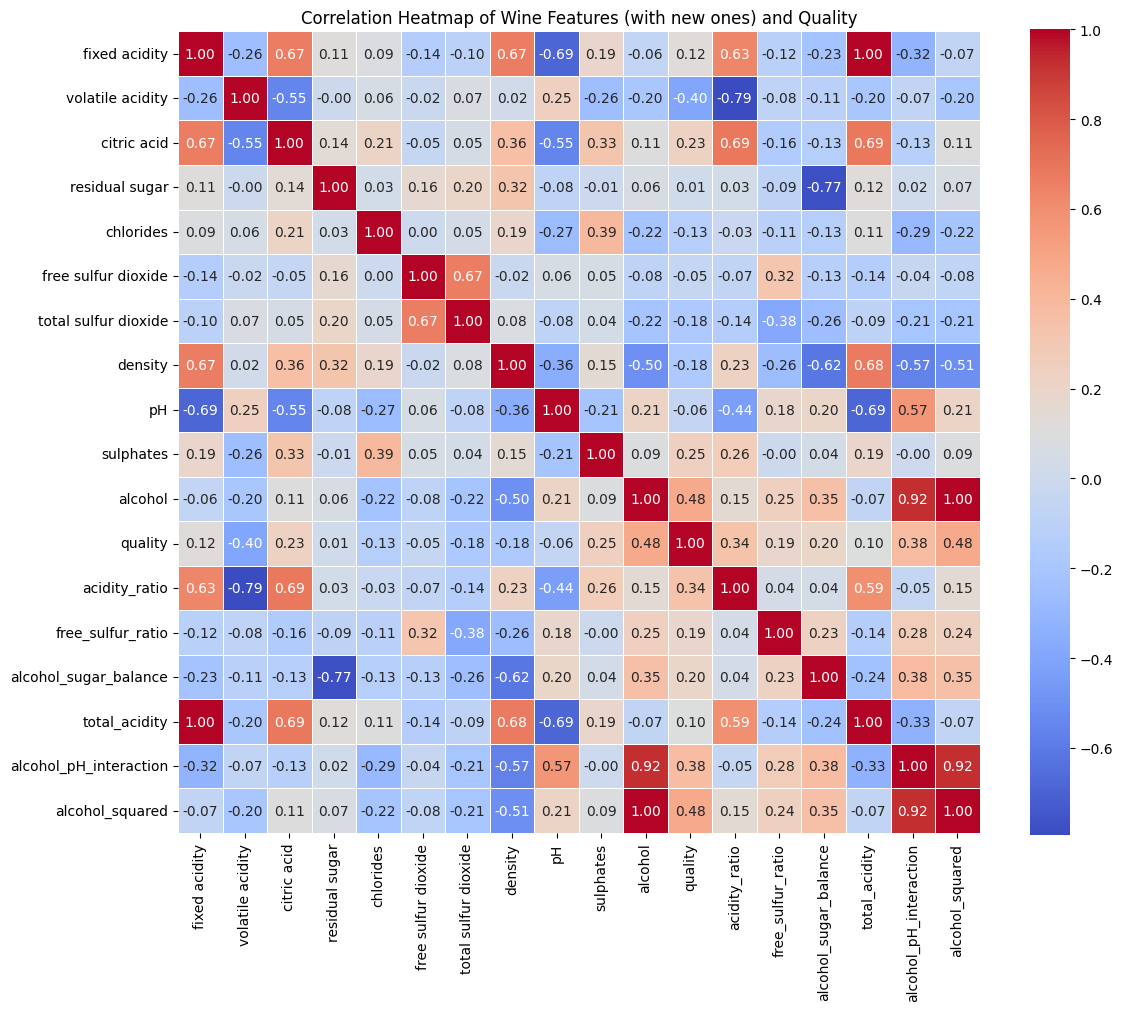


Correlation of each feature with quality:
quality                   1.000000
alcohol                   0.480343
alcohol_squared           0.477202
alcohol_pH_interaction    0.380891
acidity_ratio             0.341228
sulphates                 0.248835
citric acid               0.228057
alcohol_sugar_balance     0.195078
free_sulfur_ratio         0.192296
fixed acidity             0.119024
total_acidity             0.097936
residual sugar            0.013640
free sulfur dioxide      -0.050463
pH                       -0.055245
chlorides                -0.130988
total sulfur dioxide     -0.177855
density                  -0.184252
volatile acidity         -0.395214
Name: quality, dtype: float64


In [ ]:
#  Correlation Matrix and Heatmap after adding the new features

corr_matrix = db.corr(numeric_only=True)

print("=== Correlation Matrix ===")
display(corr_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Wine Features (with new ones) and Quality")
plt.tight_layout()
plt.show()

print("\nCorrelation of each feature with quality:")
corr_with_quality = corr_matrix["quality"].sort_values(ascending=False)
print(corr_with_quality)

In [ ]:
# Feature Selection - Remove redundant features
# Based on correlation analysis, we drop features fully captured by engineered ones

features_to_drop = [
    'fixed acidity',           # Captured in acidity_ratio and total_acidity
    'citric acid',             # Captured in total_acidity
    'free sulfur dioxide',     # Captured in free_sulfur_ratio
    'total sulfur dioxide'     # Captured in free_sulfur_ratio
]

db_selected = db.drop(columns=features_to_drop)

print(f"Features before selection: {len(db.columns)}")
print(f"Features after selection: {len(db_selected.columns)}")
print(f"Removed {len(features_to_drop)} redundant features")

Features before selection: 18
Features after selection: 14
Removed 4 redundant features


Now, we apply the log on skwed right and left features. (Go back to histograms
)

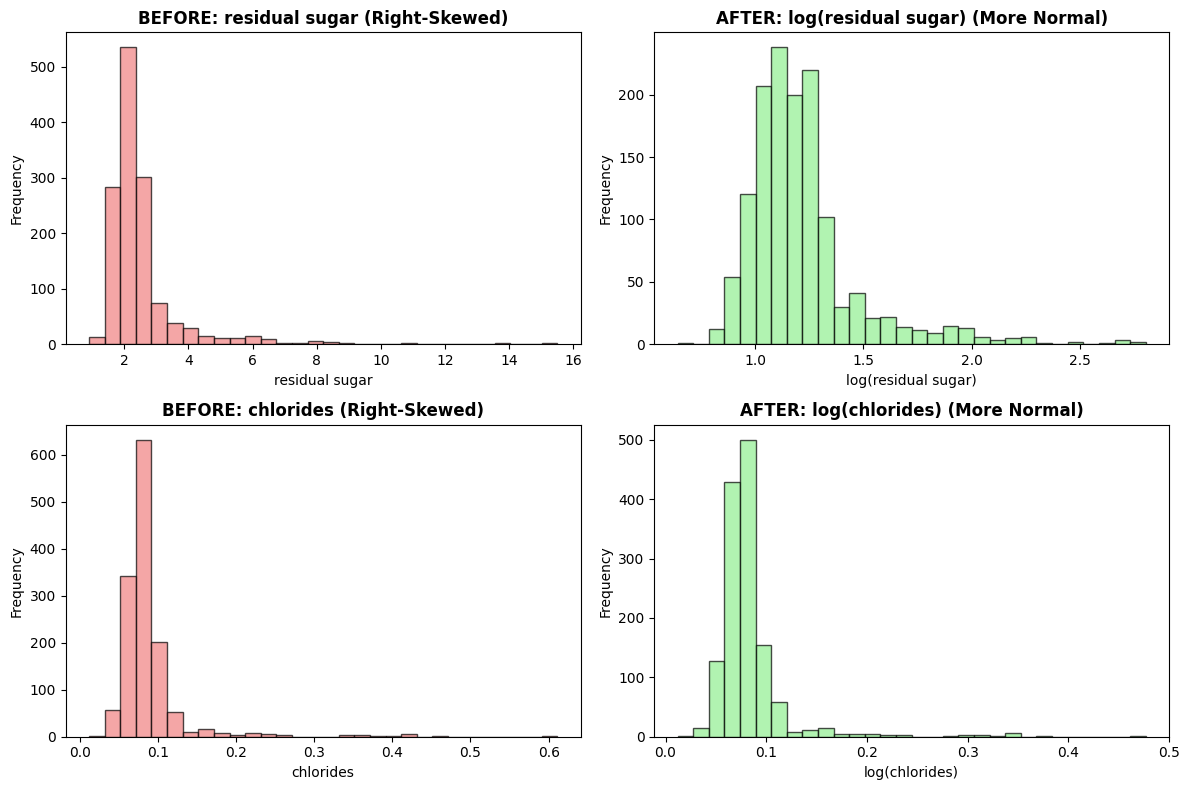

✓ Created log-transformed versions: ['residual sugar', 'chlorides']
The log-transformed versions will be used in modeling.

✓ Dropped original skewed features
Final feature count: 13 (excluding target)


In [ ]:

# Features identified as skewed in EDA
skewed_features = ['residual sugar', 'chlorides']

# Show before/after comparison
fig, axes = plt.subplots(len(skewed_features), 2, figsize=(12, 8))

for i, feature in enumerate(skewed_features):
    # BEFORE: Original distribution
    axes[i, 0].hist(db_selected[feature], bins=30, color='lightcoral',
                    edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'BEFORE: {feature} (Right-Skewed)', fontweight='bold')
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Frequency')

    # AFTER: Log-transformed distribution
    log_values = np.log1p(db_selected[feature])
    axes[i, 1].hist(log_values, bins=30, color='lightgreen',
                    edgecolor='black', alpha=0.7)
    axes[i, 1].set_title(f'AFTER: log({feature}) (More Normal)', fontweight='bold')
    axes[i, 1].set_xlabel(f'log({feature})')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Apply log transformation (log1p = log(1+x) to handle zeros)
for feature in skewed_features:
    db_selected[f'log_{feature}'] = np.log1p(db_selected[feature])

print(f"✓ Created log-transformed versions: {skewed_features}")
print("The log-transformed versions will be used in modeling.")

# Drop original skewed features to avoid redundancy
db_final = db_selected.drop(columns=skewed_features)

print(f"\n✓ Dropped original skewed features")
print(f"Final feature count: {len(db_final.columns) - 1} (excluding target)")

# 5 Identify target and feature columns


In [ ]:
target_col = "quality"                      # output variable
feature_cols = [c for c in db.columns if c != target_col]

print("Target column:", target_col)
print("Feature columns:", feature_cols)

Target column: quality
Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'acidity_ratio', 'free_sulfur_ratio', 'alcohol_sugar_balance', 'total_acidity', 'alcohol_pH_interaction', 'alcohol_squared']


# 6. Outlier Detection – IQR Method

In this section we:
- Detect potential outliers in each numeric feature using the Interquartile Range (IQR) method.
- Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR = Q3 − Q1 for each variable.
- Define lower and upper bounds as:
  - Lower bound = Q1 − 1.5 × IQR  
  - Upper bound = Q3 + 1.5 × IQR
- Count how many values fall outside these bounds (possible outliers).
- Decide whether to keep or remove these outliers depending on the context (e.g., extreme values in residual sugar or sulfur dioxide that might still represent real wines).


In [ ]:
import pandas as pd

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

rows = []
for col in feature_cols:
    n_out, lb, ub = detect_outliers_iqr(db, col)
    rows.append([col, n_out, lb, ub])

outlier_df = pd.DataFrame(rows, columns=["feature", "n_outliers", "lower_bound", "upper_bound"])
display(outlier_df)

,feature,n_outliers,lower_bound,upper_bound
0,fixed acidity,41,3.950000,12.350000
1,volatile acidity,19,0.015000,1.015000
2,citric acid,1,-0.420000,0.940000
3,residual sugar,126,0.850000,3.650000
4,chlorides,87,0.038500,0.122500
5,free sulfur dioxide,26,-14.000000,42.000000
6,total sulfur dioxide,45,-39.500000,124.500000
7,density,35,0.992270,1.001150
8,pH,28,2.925000,3.685000
9,sulphates,55,0.280000,1.000000


##N.B:

### We detect some outliers but we keep them, as they may correspond to real wines.

# 7. Class Balance – Wine Quality

In this section we:
- Examine how the target variable `quality` is distributed across different classes.
- Count the number of wine samples for each quality score using `value_counts()`.
- Visualize the class distribution with a bar plot to better understand any imbalance.
- Identify whether the dataset is balanced or imbalanced, which is critical when choosing appropriate evaluation strategies and metrics.
- Highlight the fact that qualities 5 and 6 dominate the dataset, while extreme values (3, 4, 8) are underrepresented.

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


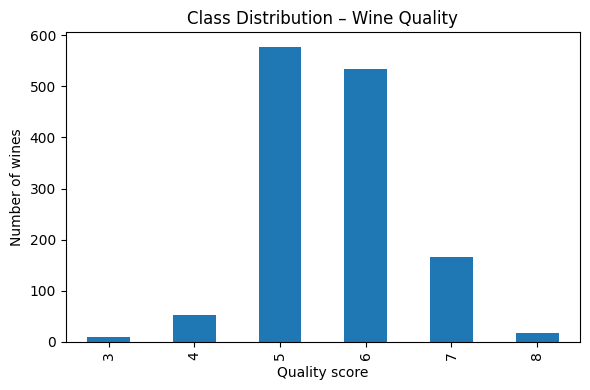

In [ ]:
print(db["quality"].value_counts().sort_index())

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
db["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution – Wine Quality")
plt.xlabel("Quality score")
plt.ylabel("Number of wines")
plt.tight_layout()
plt.show()

#N.B:
### Class Balance – Interpretation

The target variable `quality` takes integer values from 3 to 8.  
Most wines are of medium quality (5 and 6), with:

- 577 wines of quality 5  
- 535 wines of quality 6  

Very low (3–4) and very high (7–8) qualities are much less frequent.  
This means the dataset is slightly imbalanced: the models will see many more
examples of “normal” wines than of very bad or excellent wines. We will keep
all classes but interpret the evaluation metrics with this imbalance in mind.

# 8. Preparing Data for Modeling – Train/Test Split and Standardization

In this section we:
- Separate the dataset into:
  - Input features `X` (all columns except `quality`)
  - Target variable `y` (wine quality scores)
- Split the data into **training (80%)** and **test (20%)** sets using stratified sampling to maintain the distribution of quality classes.
- Standardize all input features using `StandardScaler` so that each variable has:
  - Mean = 0  
  - Standard deviation = 1
- Ensure the feature scales are uniform, which is crucial for models that rely on distance (e.g., k-NN, SVM) and neural networks.
- Output `X_train_scaled`, `X_test_scaled`, `y_train`, and `y_test`, which are used in the next phase: model training and evaluation.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 8.1 Separate X and y
X = db[feature_cols]
y = db[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

# 8.2 Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # keeps same quality proportions in train & test
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# 8.3 Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape :", X_test_scaled.shape)

X shape: (1359, 17)
y shape: (1359,)
X_train: (1087, 17)
X_test : (272, 17)

Scaled X_train shape: (1087, 17)
Scaled X_test shape : (272, 17)


### Analyse result: Interpretation of the Train/Test Split and Scaling

After cleaning and exploring the dataset, we prepared the data for modeling:

- The full dataset now contains **1 359 wines** and **11 input features**.
- We split the data into:
  - **Training set:** 1 087 samples (80%)  
  - **Test set:** 272 samples (20%)

The split is **stratified** on the target `quality`, so the distribution of
quality scores (3–8) is similar in both sets. This is important because the
classes are slightly imbalanced.

All 11 features have then been **standardized** using `StandardScaler`, giving:

- `X_train_scaled`: (1 087, 11)  
- `X_test_scaled`: (272, 11)  

Standardization (zero mean, unit variance) puts all physicochemical variables
(acidity, alcohol, sulfur, etc.) on the same scale, which is essential for
many machine learning algorithms and for the neural network we will train.


Now, we handle unbalanced DAtA:

## Handling Imbalanced Data

As identified in our EDA, the quality scores are imbalanced (many average wines,
few excellent/poor wines). We address this using two techniques:

1. **SMOTE** (Synthetic Minority Over-sampling Technique): Creates synthetic
   samples for minority classes
2. **Class Weights**: Penalizes misclassification of minority classes more heavily

**Critical:** SMOTE is applied ONLY to the training set. The test set remains
imbalanced to reflect real-world distribution.

In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply ONLY to training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(y_train.value_counts().sort_index())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts().sort_index())

print(f"\n✓ Training samples increased from {len(y_train)} to {len(y_train_balanced)}")
print("✓ Test set remains unchanged (original imbalanced distribution)")

Before SMOTE:
quality
3      8
4     42
5    461
6    428
7    134
8     14
Name: count, dtype: int64

After SMOTE:
quality
3    461
4    461
5    461
6    461
7    461
8    461
Name: count, dtype: int64

✓ Training samples increased from 1087 to 2766
✓ Test set remains unchanged (original imbalanced distribution)


# <center>**Machine learning models : Imbalanced Data**</center>





In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score)
import xgboost as xgb

print("="*80)
print("MODEL TRAINING WITH HYPERPARAMETER TUNING")
print("="*80)

MODEL TRAINING WITH HYPERPARAMETER TUNING


In [ ]:

print("\n1/3 Training Random Forest...")

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train_balanced, y_train_balanced)
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_scaled)

print(f"✓ Best params: {rf_grid.best_params_}")
print(f"✓ CV Score: {rf_grid.best_score_:.4f}")
print(f"✓ Test Score: {balanced_accuracy_score(y_test, y_pred_rf):.4f}")








1/3 Training Random Forest...
✓ Best params: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
✓ CV Score: 0.8482
✓ Test Score: 0.3264


In [ ]:
# ============================================================================
# ENCODAGE DES LABELS POUR XGBOOST
# ============================================================================

from sklearn.preprocessing import LabelEncoder

# XGBoost nécessite des labels 0, 1, 2, ... au lieu de 3, 4, 5, 6, 7, 8
label_encoder = LabelEncoder()

# Encoder les labels (fit sur train, transform sur train et test)
y_train_encoded = label_encoder.fit_transform(y_train_balanced)
y_test_encoded = label_encoder.transform(y_test)

print("Mapping des labels pour XGBoost:")
for original, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"  Qualité {original} → Label {encoded}")

print(f"\n✓ Labels encodés: {sorted(y_train_balanced.unique())} → {sorted(np.unique(y_train_encoded))}")

Mapping des labels pour XGBoost:
  Qualité 3 → Label 0
  Qualité 4 → Label 1
  Qualité 5 → Label 2
  Qualité 6 → Label 3
  Qualité 7 → Label 4
  Qualité 8 → Label 5

✓ Labels encodés: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] → [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [ ]:
# ============================================================================
# MODEL 2: XGBOOST (VERSION CORRIGÉE)
# ============================================================================

print("\n2/3 Training XGBoost...")

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.3],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    xgb_param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1
)

#IMPORTANT: Utiliser y_train_encoded au lieu de y_train_balanced
xgb_grid.fit(X_train_balanced, y_train_encoded)

xgb_best = xgb_grid.best_estimator_

# Prédire avec les labels encodés
y_pred_xgb_encoded = xgb_best.predict(X_test_scaled)

#IMPORTANT: Reconvertir en labels originaux (3, 4, 5, 6, 7, 8)
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

print(f"✓ Best params: {xgb_grid.best_params_}")
print(f"✓ CV Score: {xgb_grid.best_score_:.4f}")
print(f"✓ Test Score: {balanced_accuracy_score(y_test, y_pred_xgb):.4f}")


2/3 Training XGBoost...
✓ Best params: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
✓ CV Score: 0.8435
✓ Test Score: 0.2997


In [ ]:
# ============================================================================
# MODEL 3: LOGISTIC REGRESSION (BASELINE)
# ============================================================================

print("\n3/3 Training Logistic Regression...")

lr_param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'class_weight': ['balanced'],
    'max_iter': [1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1
)

lr_grid.fit(X_train_balanced, y_train_balanced)
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test_scaled)

print(f"✓ Best params: {lr_grid.best_params_}")
print(f"✓ CV Score: {lr_grid.best_score_:.4f}")
print(f"✓ Test Score: {balanced_accuracy_score(y_test, y_pred_lr):.4f}")





3/3 Training Logistic Regression...
✓ Best params: {'C': 10, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
✓ CV Score: 0.6674
✓ Test Score: 0.2732



MODEL COMPARISON

               Model  CV Score  Test Score
      Random Forest  0.848192    0.326420
            XGBoost  0.843490    0.299687
Logistic Regression  0.667395    0.273217


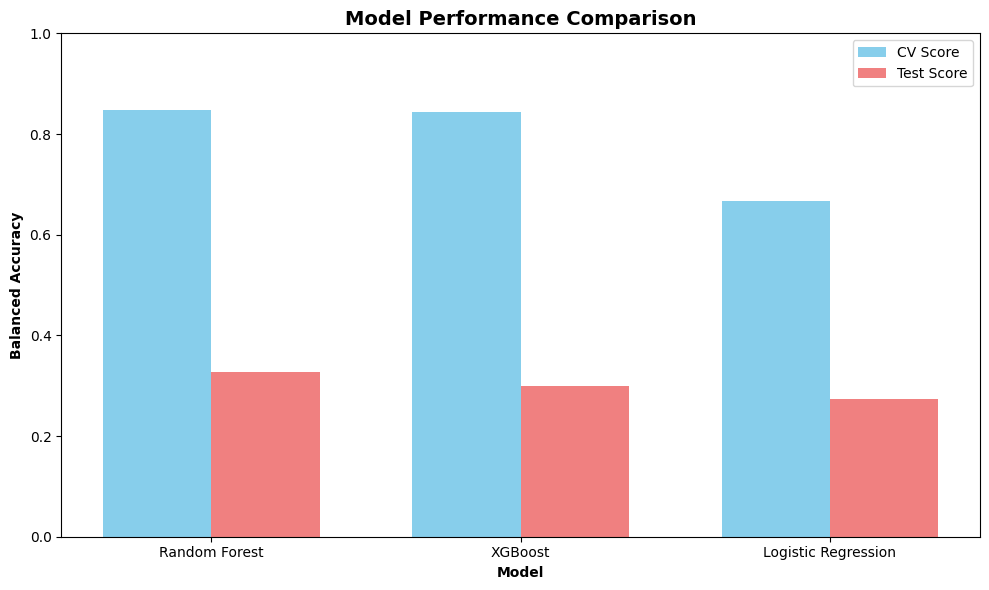


🏆 Best Model: Random Forest
   Test Balanced Accuracy: 0.3264


In [ ]:
# ============================================================================
# MODEL COMPARISON
# ============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Logistic Regression'],
    'CV Score': [rf_grid.best_score_, xgb_grid.best_score_, lr_grid.best_score_],
    'Test Score': [
        balanced_accuracy_score(y_test, y_pred_rf),
        balanced_accuracy_score(y_test, y_pred_xgb),
        balanced_accuracy_score(y_test, y_pred_lr)
    ]
}).sort_values('Test Score', ascending=False)

print("\n", results.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
x = np.arange(len(results))
width = 0.35

plt.bar(x - width/2, results['CV Score'], width, label='CV Score', color='skyblue')
plt.bar(x + width/2, results['Test Score'], width, label='Test Score', color='lightcoral')

plt.xlabel('Model', fontweight='bold')
plt.ylabel('Balanced Accuracy', fontweight='bold')
plt.title('Model Performance Comparison', fontweight='bold', fontsize=14)
plt.xticks(x, results['Model'])
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Select best model
best_model_name = results.iloc[0]['Model']
best_model = {'Random Forest': rf_best, 'XGBoost': xgb_best, 'Logistic Regression': lr_best}[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test Balanced Accuracy: {results.iloc[0]['Test Score']:.4f}")





DETAILED EVALUATION: Random Forest

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.16      0.27      0.20        11
           5       0.69      0.64      0.66       116
           6       0.58      0.53      0.55       107
           7       0.42      0.52      0.47        33
           8       0.00      0.00      0.00         3

    accuracy                           0.56       272
   macro avg       0.31      0.33      0.31       272
weighted avg       0.58      0.56      0.57       272



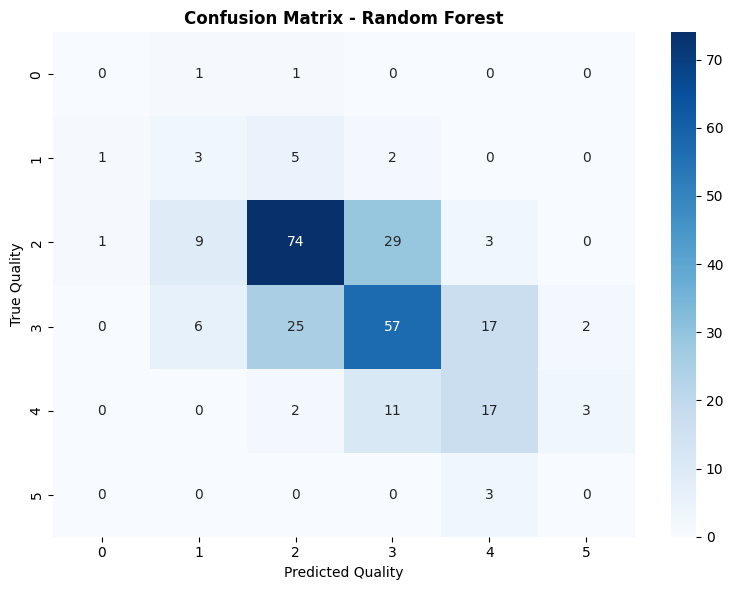


Top 10 Most Important Features:
               Feature  Importance
             sulphates    0.104259
      volatile acidity    0.095612
         acidity_ratio    0.083237
       alcohol_squared    0.082322
               alcohol    0.076242
  total sulfur dioxide    0.058689
             chlorides    0.055841
alcohol_pH_interaction    0.053833
           citric acid    0.053647
                    pH    0.051320


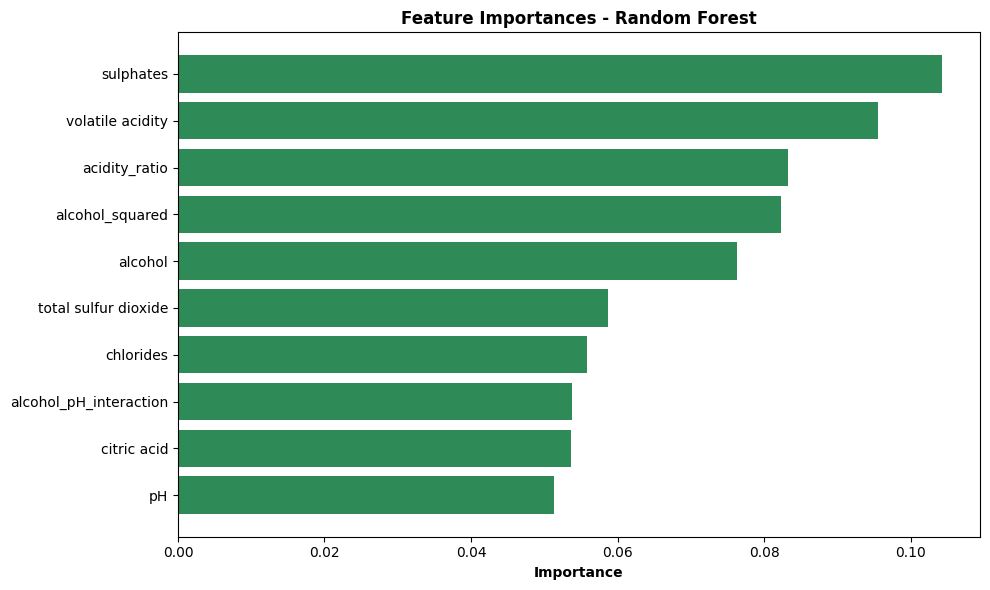


✓ Model training complete!


In [ ]:
# ============================================================================
# DETAILED EVALUATION OF BEST MODEL
# ============================================================================

print("\n" + "="*80)
print(f"DETAILED EVALUATION: {best_model_name}")
print("="*80)

y_pred_best = best_model.predict(X_test_scaled)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
plt.ylabel('True Quality')
plt.xlabel('Predicted Quality')
plt.tight_layout()
plt.show()

# Feature Importance (for tree models)
if best_model_name in ['Random Forest', 'XGBoost']:
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    # Visualize
    plt.figure(figsize=(10, 6))
    top_10 = feature_importance.head(10)
    plt.barh(top_10['Feature'], top_10['Importance'], color='seagreen')
    plt.xlabel('Importance', fontweight='bold')
    plt.title(f'Feature Importances - {best_model_name}', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print("\n✓ Model training complete!")

In [ ]:
# ============================================================================
# GRID SEARCH ÉLARGI - Plus de combinaisons
# ============================================================================

# Random Forest - Paramètres étendus
rf_param_grid_extended = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'class_weight': ['balanced', 'balanced_subsample'],
    'bootstrap': [True, False]
}

# Utilise RandomizedSearchCV (plus rapide que GridSearch)
from sklearn.model_selection import RandomizedSearchCV

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid_extended,
    n_iter=50,  # Teste 50 combinaisons aléatoires
    cv=5,
    scoring='balanced_accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train_balanced, y_train_balanced)

print(f"Meilleurs paramètres: {rf_random.best_params_}")
print(f"Meilleur CV score: {rf_random.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Meilleurs paramètres: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 15, 'class_weight': 'balanced', 'bootstrap': False}
Meilleur CV score: 0.8547
